# Brain Street View - Example Notebook
Load and plot Allen Mouse Brain Connectivity data ([Oh et al., Nature, 2014](https://doi.org/10.1038/nature13186))

In [1]:
%matplotlib inline
import bsv

## Parameters

In [9]:
# local paths — update these to match your setup
save_location = '/home/julie/Dropbox/Data/AllenQueries'
allen_atlas_path = '/home/julie/Dropbox/Atlas/allenCCF'
allen_atlas_path_v2 = '/home/julie/Dropbox/Atlas/allenCCF_v2'  # for subregion analysis
file_name = ''

# experiment parameters
input_regions = [ 'VISam']
mouse_line = ''
primary_injection = True

# loading parameters
subtract_other_hemisphere = False
normalization_method = 'injectionIntensity'

# plotting parameters
number_of_slices = 10
number_of_pixels = 15
output_region = 'CP'
plane = 'coronal'
smoothing = 2
color_limits = 'global'
region_only = True
color = [[0.543, 0, 0], [0, 0.746, 1], [0.180, 0.543, 0.340], [1, 0.547, 0]]

## 1. Find Allen connectivity experiments

In [10]:
experiment_ids = bsv.find_connectivity_experiments(input_regions, mouse_line, primary_injection)
print(f'\nTotal: {len(experiment_ids)} experiments')

Found 38 experiments in VISam

Total: 38 experiments


## 2. Fetch/load experiment data
The first run downloads images from the Allen API and caches them locally. Subsequent runs load from cache.

In [11]:
experiment_imgs, injection_summary, _, experiment_region_info = bsv.fetch_connectivity_data(
    experiment_ids, save_location, file_name,
    normalization_method, subtract_other_hemisphere,
    allen_atlas_path=allen_atlas_path)

print(f'Projection data shape: {experiment_imgs.shape}')

Loading 38 experiments...

EXPERIMENT SUMMARY
Total experiments loaded: 38

Mouse genotype distribution:
  Tlx3-Cre_PL56: 6 experiments
  Ai75(RCL-nT): 6 experiments
  Cux2-IRES-Cre: 5 experiments
  Wild-type: 3 experiments
  Rbp4-Cre_KL100: 3 experiments
  Ntsr1-Cre_GN220: 3 experiments
  Emx1-IRES-Cre: 2 experiments
  Scnn1a-Tg3-Cre: 2 experiments
  A930038C07Rik-Tg1-Cre: 2 experiments
  Gpr26-Cre_KO250: 1 experiments
  Trib2-F2A-CreERT2: 1 experiments
  Drd3-Cre_KI196: 1 experiments
  Efr3a-Cre_NO108: 1 experiments
  Sst-IRES-Cre: 1 experiments
  Sim1-Cre_KJ18: 1 experiments

Brain region distribution:
  VISam: 38 experiments
Getting raw images...
Metadata exported to: /home/julie/Dropbox/Data/AllenQueries/connectivity_data_metadata.csv
Data processing complete.
Projection data shape: (132, 80, 114, 1)


## 3. Plot projections to target region (2D)

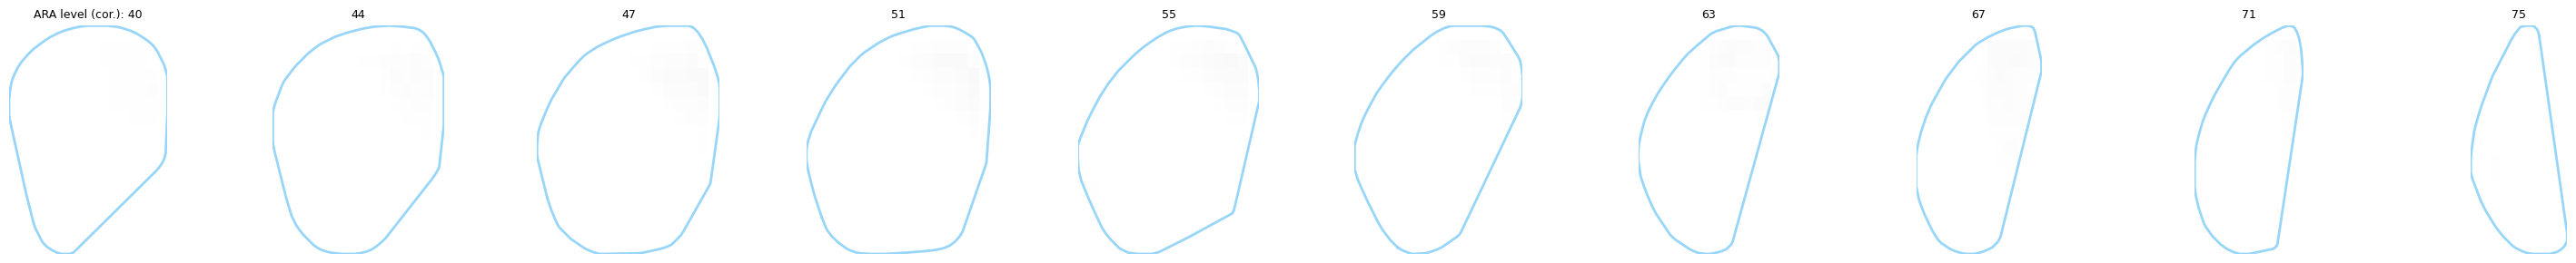

In [16]:
proj_array, proj_coords = bsv.plot_connectivity(
    experiment_imgs, allen_atlas_path, output_region,
    number_of_slices, number_of_pixels, plane,
    region_only, smoothing, color_limits, color, normalization_method)

In [14]:
proj_array

array([[[1.56866307e-05, 3.35725034e-19, 1.57015185e-17, ...,
         1.54005005e-05, 1.01224970e-04, 2.97998087e-03],
        [1.17740386e-07, 8.58096638e-06, 0.00000000e+00, ...,
         5.32337621e-08, 3.37702120e-04, 3.03588372e-03],
        [6.35141491e-06, 7.71889781e-07, 4.05718221e-05, ...,
         7.83444079e-05, 6.51461298e-04, 3.32879339e-03],
        ...,
        [4.52896878e-06, 4.43052767e-05, 7.15526422e-06, ...,
         9.75708137e-04, 1.52276545e-04, 2.19804133e-04],
        [1.62383834e-07, 1.79819726e-05, 9.24365410e-06, ...,
         4.78946726e-05, 1.03941647e-04, 1.16033911e-04],
        [2.60547570e-06, 2.40582361e-16, 1.05389007e-05, ...,
         7.16790784e-06, 8.51702213e-05, 1.02399355e-04]],

       [[4.45022757e-05, 0.00000000e+00, 6.25812488e-06, ...,
         2.66308473e-05, 2.62616916e-04, 3.62188804e-03],
        [2.56295040e-06, 1.23902015e-17, 5.13062586e-17, ...,
         3.30118793e-05, 4.97431542e-04, 3.11112975e-03],
        [4.78378076e-07, 

## 4. Plot with region grouping
Group input regions and plot each group as a separate row.

In [13]:
# group visual regions: e.g. VISp alone, VISl+VISal together, rest together
region_groups = [1, 2, 2, 3, 3, 3, 3, 3]

# re-fetch with grouping
experiment_imgs_grouped, _, _, _ = bsv.fetch_connectivity_data(
    experiment_ids, save_location, file_name,
    normalization_method, subtract_other_hemisphere,
    allen_atlas_path=allen_atlas_path,
    input_regions=input_regions, region_groups=region_groups)

proj_array_grouped, _ = bsv.plot_connectivity(
    experiment_imgs_grouped, allen_atlas_path, output_region,
    number_of_slices, number_of_pixels, plane,
    region_only, smoothing, color_limits, color, normalization_method,
    input_regions=input_regions, region_groups=region_groups,
    experiment_region_info=experiment_region_info)

Loading 38 experiments...

EXPERIMENT SUMMARY
Total experiments loaded: 38

Mouse genotype distribution:
  Tlx3-Cre_PL56: 6 experiments
  Ai75(RCL-nT): 6 experiments
  Cux2-IRES-Cre: 5 experiments
  Wild-type: 3 experiments
  Rbp4-Cre_KL100: 3 experiments
  Ntsr1-Cre_GN220: 3 experiments
  Emx1-IRES-Cre: 2 experiments
  Scnn1a-Tg3-Cre: 2 experiments
  A930038C07Rik-Tg1-Cre: 2 experiments
  Gpr26-Cre_KO250: 1 experiments
  Trib2-F2A-CreERT2: 1 experiments
  Drd3-Cre_KI196: 1 experiments
  Efr3a-Cre_NO108: 1 experiments
  Sst-IRES-Cre: 1 experiments
  Sim1-Cre_KJ18: 1 experiments

Brain region distribution:
  VISam: 38 experiments
Region-based grouping: 37 experiments mapped to 3 groups
Getting raw images...
Metadata exported to: /home/julie/Dropbox/Data/AllenQueries/connectivity_data_metadata.csv
Data processing complete.


ValueError: Length of region_groups (8) must match input_regions (1)

## 5. Thresholded connectivity

In [ ]:
thresh_array, thresh_coords = bsv.threshold_connectivity(
    experiment_imgs, allen_atlas_path, output_region,
    number_of_slices, number_of_pixels, plane,
    region_only, smoothing, color_limits, color,
    threshold=90, threshold_method='percentile',
    normalization_method='none', data_fetch_normalization=normalization_method)

## 6. 3D visualization

In [ ]:
bsv.plot_connectivity_3d(injection_summary, allen_atlas_path, output_region,
                         color, plot_patch=True)

## 7. CP subregion analysis
Analyze projection intensity per striatum (CP + NAc) subregion using the Allen v2 atlas.

In [ ]:
subregion_results, global_results = bsv.analyze_cp_subregions(
    proj_array, proj_coords, allen_atlas_path_v2)

## 8. Combined connectivity + subregion analysis
Run plotting and subregion analysis in one call.

In [ ]:
proj_array, proj_coords, sub_results, glob_results = bsv.plot_connectivity_with_subregion_analysis(
    experiment_imgs, allen_atlas_path, allen_atlas_path_v2, output_region,
    number_of_slices, number_of_pixels, plane,
    region_only, smoothing, color_limits, color, normalization_method)

## 9. Export subregion results to CSV

In [ ]:
import os

csv_path = os.path.join(save_location, 'cp_subregion_analysis.csv')
sub_results, glob_results = bsv.analyze_cp_subregions(
    proj_array, proj_coords, allen_atlas_path_v2,
    save_csv_path=csv_path)

print(f'Results saved to: {csv_path}')